# Usuwanie linii pięciolinii – porównanie metod

Cel: jak najdokładniej usunąć linie pięciolinii **bez niszczenia** nut, kluczy i metrum.

Testujemy trzy podejścia:
| Metoda | Idea | Zalety | Wady |
|--------|------|--------|------|
| **A – Morph OPEN** | Kernel poziomy ≥60% szerokości obrazu | Prosta, szybka | Może urywać nuty przy cienkiej linii |
| **B – Projection Profile** | Suma pikseli na wiersz → szukaj wierszy z fill>0.6 | Precyzyjna lokalizacja | Wymaga dobrego progu |
| **C – Run-Length** | Usuwa tylko piksele należące do długich ciągów poziomych | Najdokładniejsza, per-piksel | Trochę wolniejsza |

Po każdej metodzie stosujemy **naprawę pionową** (`MORPH_CLOSE`), żeby skleić nuty przecięte przez linie.

Rozmiar po skalowaniu: 64×188 px


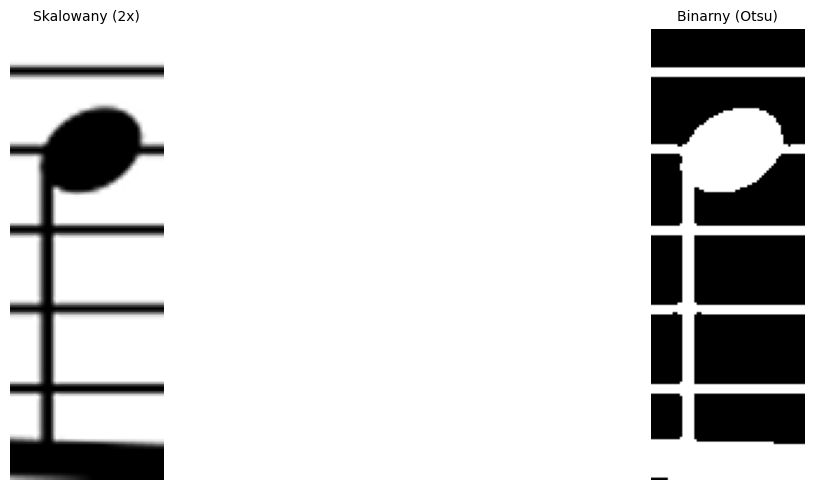

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

IMAGE_PATH   = '../data/note_dataset/notes/images/000000.png'
SCALE_FACTOR = 2      # powiększenie przed przetwarzaniem

# ──────────────────────────────────────────
# Pomocnicze
# ──────────────────────────────────────────
def show(*imgs_titles, figsize_w=18):
    n = len(imgs_titles) // 2
    fig, axes = plt.subplots(1, n, figsize=(figsize_w, 5))
    if n == 1: axes = [axes]
    for ax, img, title in zip(axes, imgs_titles[::2], imgs_titles[1::2]):
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout(); plt.show()

def binarize(img_gray):
    """Otsu, czarne nuty → białe piksele."""
    _, b = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return b

def scale_img(img, factor):
    if factor == 1: return img.copy()
    return cv2.resize(img, None, fx=factor, fy=factor, interpolation=cv2.INTER_CUBIC)

def repair_vertical(binary, scale=SCALE_FACTOR, kh=None):
    """Morfologiczne zamknięcie pionowe – skleja części symboli przecięte przez linie."""
    if kh is None: kh = max(5, 3 * scale)
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (1, kh))
    return cv2.morphologyEx(binary, cv2.MORPH_CLOSE, k)

# ──────────────────────────────────────────
# Wczytaj i skaluj
# ──────────────────────────────────────────
img_orig  = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
img_s     = scale_img(img_orig, SCALE_FACTOR)
binary    = binarize(img_s)

H, W = binary.shape
print(f'Rozmiar po skalowaniu: {W}×{H} px')

show(img_s, f'Skalowany ({SCALE_FACTOR}x)', binary, 'Binarny (Otsu)')

## Diagnostyka – projection profile

Zanim wybierzemy metodę, zobaczmy jak wygląda profil poziomy.
Linie pięciolinii dają **ostre szpice** blisko 1.0 – nuty i klucze mają niższe wartości.

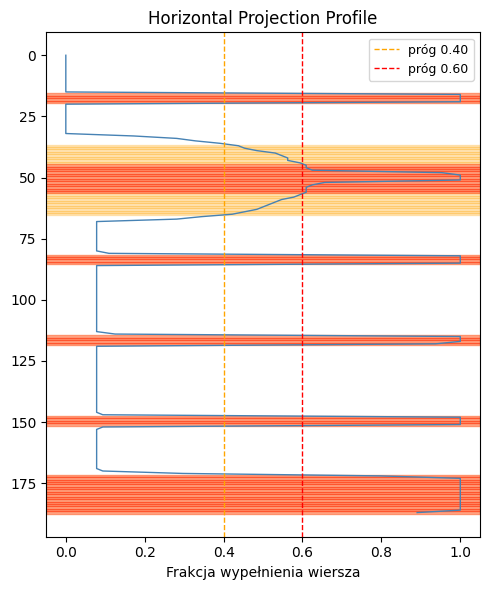

  fill ≥ 0.4: 61 wierszy
  fill ≥ 0.5: 55 wierszy
  fill ≥ 0.6: 44 wierszy
  fill ≥ 0.7: 36 wierszy
  fill ≥ 0.8: 35 wierszy


In [2]:
profile = binary.sum(axis=1) / (W * 255)

fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(profile, np.arange(H), color='steelblue', lw=1)
ax.invert_yaxis()
ax.set_xlabel('Frakcja wypełnienia wiersza')
ax.set_title('Horizontal Projection Profile')

for thresh, color, label in [(0.4, 'orange', '0.40'), (0.6, 'red', '0.60')]:
    ax.axvline(x=thresh, color=color, ls='--', lw=1, label=f'próg {label}')
    mask = profile >= thresh
    for y in np.where(mask)[0]:
        ax.axhspan(y-0.5, y+0.5, color=color, alpha=0.25)

ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

for t in [0.4, 0.5, 0.6, 0.7, 0.8]:
    cnt = (profile >= t).sum()
    print(f'  fill ≥ {t:.1f}: {cnt} wierszy')

## Metoda A – Morphological OPEN

Kernel poziomy o szerokości ≥ `LINE_RATIO` × W i **wysokości 1 px** wyizoluje tylko piksele należące do bardzo długich ciągłych linii.  
Następnie dylatujemy je pionowo, żeby objąć pełną grubość linii (przy 2x skali linia ma ~2 px).

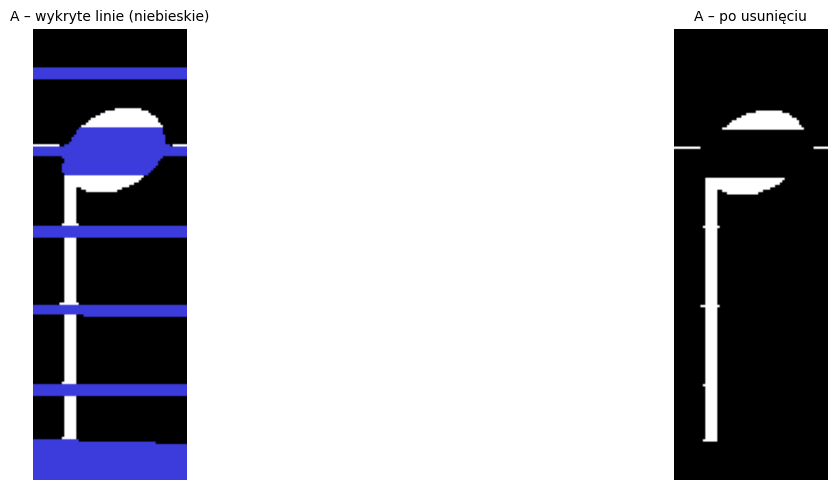

In [3]:
def remove_lines_morph(binary, line_ratio=0.55, line_thickness=None, scale=SCALE_FACTOR,
                        do_repair=True):
    """
    Usuwa linie pięciolinii morfologicznym OPEN.

    Args:
        line_ratio      : minimalna długość linii jako ułamek szerokości obrazu
        line_thickness  : grubość linii w px (None = auto: 1*scale)
        do_repair       : czy stosować pionowe zamknięcie po usunięciu

    Returns:
        no_lines   : binarny bez linii
        lines_mask : maska wykrytych linii
    """
    H, W = binary.shape
    if line_thickness is None:
        line_thickness = max(1, scale)  # 1 px na oryginalnej skali

    # Detekcja: OPEN z wąskim poziomym kernelem
    klen = max(10, int(W * line_ratio))
    k_detect = cv2.getStructuringElement(cv2.MORPH_RECT, (klen, 1))
    lines_thin = cv2.morphologyEx(binary, cv2.MORPH_OPEN, k_detect)

    # Poszerzenie pionowe – obejmij pełną grubość linii
    k_thick = cv2.getStructuringElement(cv2.MORPH_RECT, (1, line_thickness))
    lines_mask = cv2.dilate(lines_thin, k_thick)

    # Odejmowanie
    no_lines = cv2.subtract(binary, lines_mask)

    if do_repair:
        no_lines = repair_vertical(no_lines, scale)

    return no_lines, lines_mask


A_result, A_mask = remove_lines_morph(binary)

# Wizualizacja: zaznacz wykryte linie na kolorowym obrazie
overlay_A = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
overlay_A[A_mask > 0] = (60, 60, 220)  # linie na niebiesko

show(overlay_A, 'A – wykryte linie (niebieskie)', A_result, 'A – po usunięciu')

## Metoda B – Projection Profile (poprawiona)

Szukamy wierszy z wypełnieniem ≥ `min_fill` – ale teraz próg to **0.6**, nie 0.4.  
Kluczowe: zerujemy tylko piksele **w wykrytych wierszach**, które należą do długich poziomych ciągów (≥ `min_run_ratio` × W). Piksele nut (krótkie ciągi) zostają.

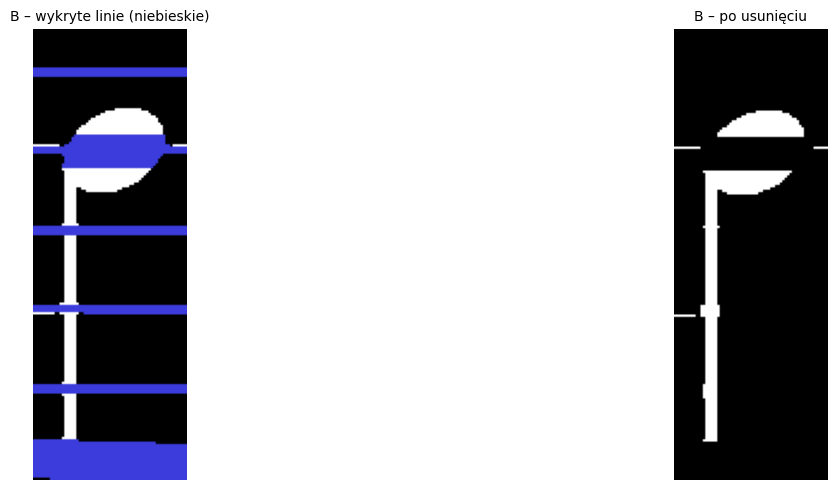

In [4]:
def find_staff_rows(binary, min_fill=0.6, margin=1):
    """
    Zwraca maskę boolowską wierszy należących do linii pięciolinii.
    margin: ile dodatkowych wierszy (góra/dół) dodać do każdej linii
    """
    H, W = binary.shape
    profile = binary.sum(axis=1) / (W * 255)
    is_line = profile >= min_fill

    # Rozszerz o margin w górę i dół
    mask = is_line.copy()
    for d in range(1, margin + 1):
        mask[d:] |= is_line[:-d]
        mask[:-d] |= is_line[d:]
    return mask


def remove_lines_projection(binary, min_fill=0.6, min_run_ratio=0.25,
                             margin=1, scale=SCALE_FACTOR, do_repair=True):
    """
    Usuwa linie pięciolinii używając projection profile + filtr długości ciągów.

    Args:
        min_fill      : minimalne wypełnienie wiersza żeby uznać go za linię (0.6 = 60%)
        min_run_ratio : w wykrytych wierszach, usuwa tylko ciągi poziome >= min_run_ratio × W
        margin        : rozszerzenie maski wierszy (px góra/dół)

    Returns:
        no_lines   : binarny bez linii
        lines_mask : maska usuniętych pikseli
    """
    H, W = binary.shape
    row_mask = find_staff_rows(binary, min_fill, margin)

    # W wykrytych wierszach zostaw tylko długie ciągi
    min_run = max(5, int(W * min_run_ratio))
    lines_mask = np.zeros_like(binary)

    for y in np.where(row_mask)[0]:
        row = binary[y]
        # Znajdź wszystkie ciągi białych pikseli w tym wierszu
        padded = np.concatenate([[0], row.astype(np.int16), [0]])
        starts = np.where((padded[:-1] == 0) & (padded[1:] == 255))[0]
        ends   = np.where((padded[:-1] == 255) & (padded[1:] == 0))[0]
        for s, e in zip(starts, ends):
            if (e - s) >= min_run:          # długi ciąg → linia pięciolinii
                lines_mask[y, s:e] = 255

    no_lines = cv2.subtract(binary, lines_mask)

    if do_repair:
        no_lines = repair_vertical(no_lines, scale)

    return no_lines, lines_mask


B_result, B_mask = remove_lines_projection(binary)

overlay_B = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
overlay_B[B_mask > 0] = (60, 60, 220)

show(overlay_B, 'B – wykryte linie (niebieskie)', B_result, 'B – po usunięciu')

## Metoda C – Run-Length (per-piksel, bez zakładania pozycji linii)

Najbardziej ogólna metoda: **każdy piksel** jest usuwany tylko wtedy, gdy należy do ciągu poziomego o długości ≥ `min_run_ratio` × W.  
Nie zakłada nic o pozycji ani liczbie linii pięciolinii.

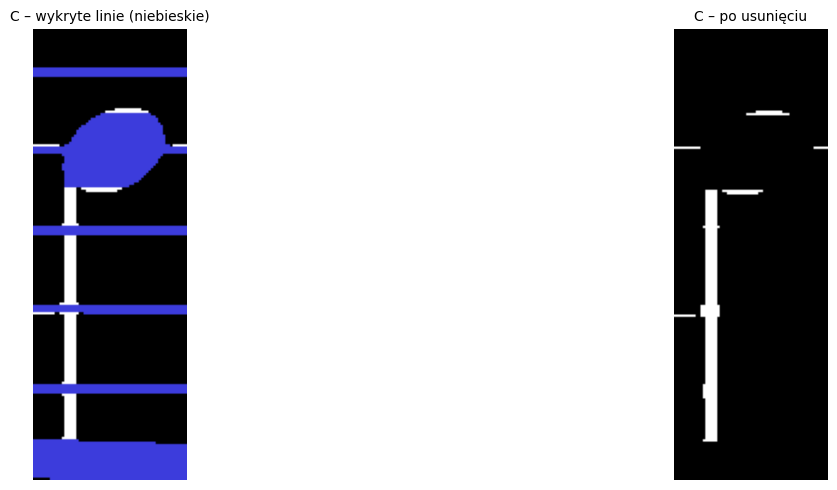

In [5]:
def build_run_length_mask(binary, min_run_ratio=0.30):
    """
    Dla każdego wiersza wyznacza piksele należące do ciągów poziomych
    o długości ≥ min_run_ratio × szerokość_obrazu.

    Returns:
        mask : uint8 binary mask, 255 = piksel długiego ciągu
    """
    H, W = binary.shape
    min_run = max(5, int(W * min_run_ratio))
    mask = np.zeros_like(binary)

    for y in range(H):
        row = binary[y]
        padded = np.concatenate([[0], row.astype(np.int16), [0]])
        starts = np.where((padded[:-1] == 0) & (padded[1:] == 255))[0]
        ends   = np.where((padded[:-1] == 255) & (padded[1:] == 0))[0]
        for s, e in zip(starts, ends):
            if (e - s) >= min_run:
                mask[y, s:e] = 255
    return mask


def remove_lines_runlength(binary, min_run_ratio=0.30, scale=SCALE_FACTOR, do_repair=True):
    """
    Usuwa linie pięciolinii metodą run-length (per-piksel).

    Args:
        min_run_ratio : minimalna długość ciągu poziomego jako ułamek szerokości (0.25–0.45)
                        niższe = bardziej agresywne usuwanie

    Returns:
        no_lines   : binarny bez linii
        lines_mask : maska usuniętych pikseli
    """
    lines_mask = build_run_length_mask(binary, min_run_ratio)
    no_lines   = cv2.subtract(binary, lines_mask)

    if do_repair:
        no_lines = repair_vertical(no_lines, scale)

    return no_lines, lines_mask


C_result, C_mask = remove_lines_runlength(binary)

overlay_C = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
overlay_C[C_mask > 0] = (60, 60, 220)

show(overlay_C, 'C – wykryte linie (niebieskie)', C_result, 'C – po usunięciu')

## Porównanie wszystkich metod

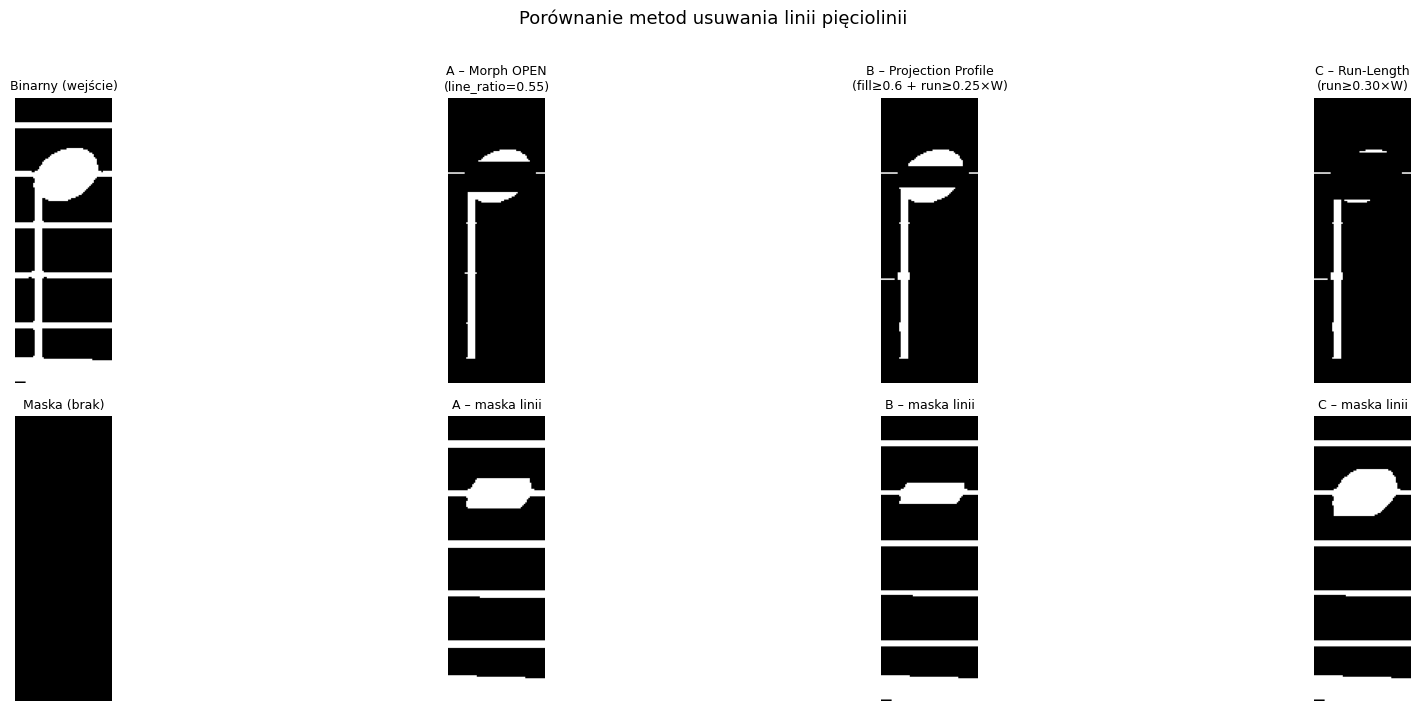

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 7))

imgs = [
    (binary,              'Binarny (wejście)'),
    (A_result,            'A – Morph OPEN\n(line_ratio=0.55)'),
    (B_result,            'B – Projection Profile\n(fill≥0.6 + run≥0.25×W)'),
    (C_result,            'C – Run-Length\n(run≥0.30×W)'),
]

masks = [
    (np.zeros_like(binary), 'Maska (brak)'),
    (A_mask,                'A – maska linii'),
    (B_mask,                'B – maska linii'),
    (C_mask,                'C – maska linii'),
]

for ax, (im, title) in zip(axes[0], imgs):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

for ax, (m, title) in zip(axes[1], masks):
    ax.imshow(m, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.suptitle('Porównanie metod usuwania linii pięciolinii', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Diagnostyka jakości – ile pikseli symboli zostało usuniętych?

Mierzymy `fałszywe negatywy`: piksele, które powinny należeć do symboli, ale zostały usunięte przez metodę.

In [7]:
# Referencja: binarny bez naprawy (same nuty + linie)
# Porównanie: różnica między wynikiem a czystymi nutami
# Prosta heurystyka: ile pikseli straciły poszczególne metody vs oryginał

total_white = int(binary.sum() // 255)
print(f'Białe piksele w obrazie binarnym: {total_white}')
print()

for name, result, mask in [
    ('A – Morph OPEN',        A_result, A_mask),
    ('B – Projection Profile', B_result, B_mask),
    ('C – Run-Length',         C_result, C_mask),
]:
    removed     = int(mask.sum() // 255)
    remaining   = int(result.sum() // 255)
    added_back  = remaining - (total_white - removed)   # dodane przez repair
    pct_removed = 100 * removed / total_white
    print(f'{name}')
    print(f'  Wykryte piksele linii : {removed:5d}  ({pct_removed:.1f}% oryginału)')
    print(f'  Pozostało białych     : {remaining:5d}')
    print(f'  Dodane przez repair   : {added_back:+d}')
    print()

Białe piksele w obrazie binarnym: 3754

A – Morph OPEN
  Wykryte piksele linii :  3162  (84.2% oryginału)
  Pozostało białych     :   928
  Dodane przez repair   : +336

B – Projection Profile
  Wykryte piksele linii :  2655  (70.7% oryginału)
  Pozostało białych     :  1167
  Dodane przez repair   : +68

C – Run-Length
  Wykryte piksele linii :  3188  (84.9% oryginału)
  Pozostało białych     :   634
  Dodane przez repair   : +68



## Strojenie parametrów – metoda C (Run-Length)

Metoda C jest najbardziej ogólna. Kluczowy parametr: `min_run_ratio`.
- **za małe** (0.15–0.20) → usuwa fragmenty ligatur i beleczek nut
- **za duże** (0.50+) → zostawia fragmenty linii pięciolinii
- **optymalne** zazwyczaj 0.25–0.40

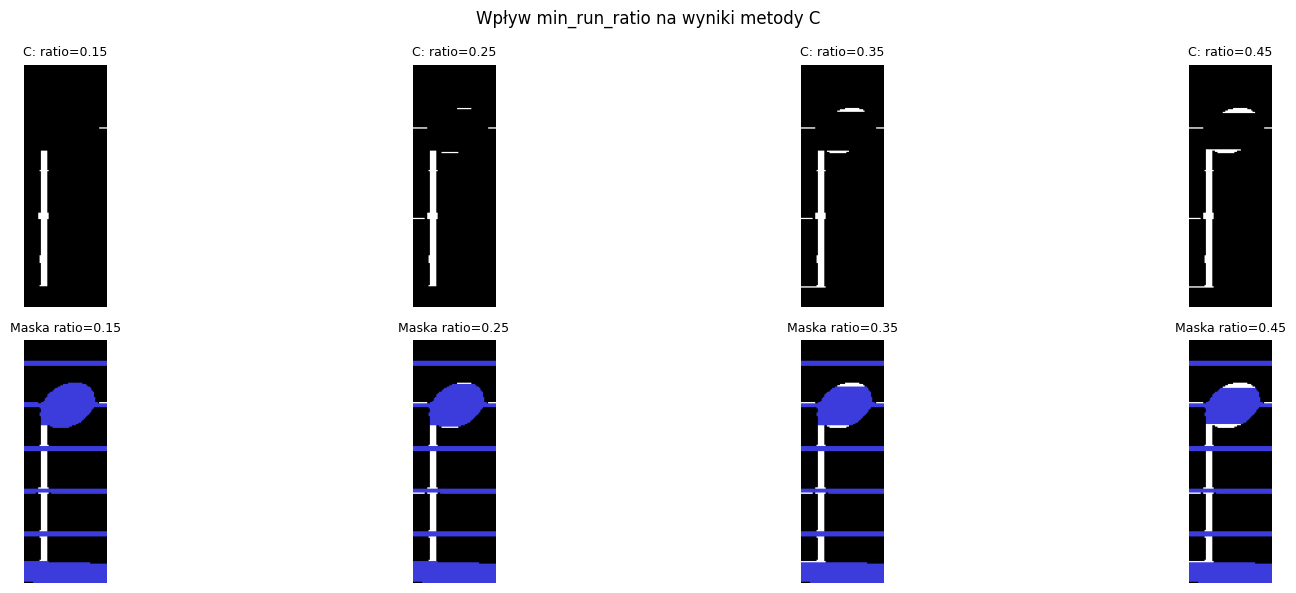

In [8]:
ratios = [0.15, 0.25, 0.35, 0.45]

fig, axes = plt.subplots(2, len(ratios), figsize=(18, 6))
for i, r in enumerate(ratios):
    res, msk = remove_lines_runlength(binary, min_run_ratio=r)
    axes[0, i].imshow(res, cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(f'C: ratio={r}', fontsize=9)
    axes[0, i].axis('off')

    overlay = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
    overlay[msk > 0] = (60, 60, 220)
    axes[1, i].imshow(overlay)
    axes[1, i].set_title(f'Maska ratio={r}', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Wpływ min_run_ratio na wyniki metody C', fontsize=12)
plt.tight_layout(); plt.show()

## Najlepsza metoda – gotowa funkcja do użycia w pipeline GHT

Na podstawie porównania wybieramy metodę i eksportujemy ją do dalszego użytku.

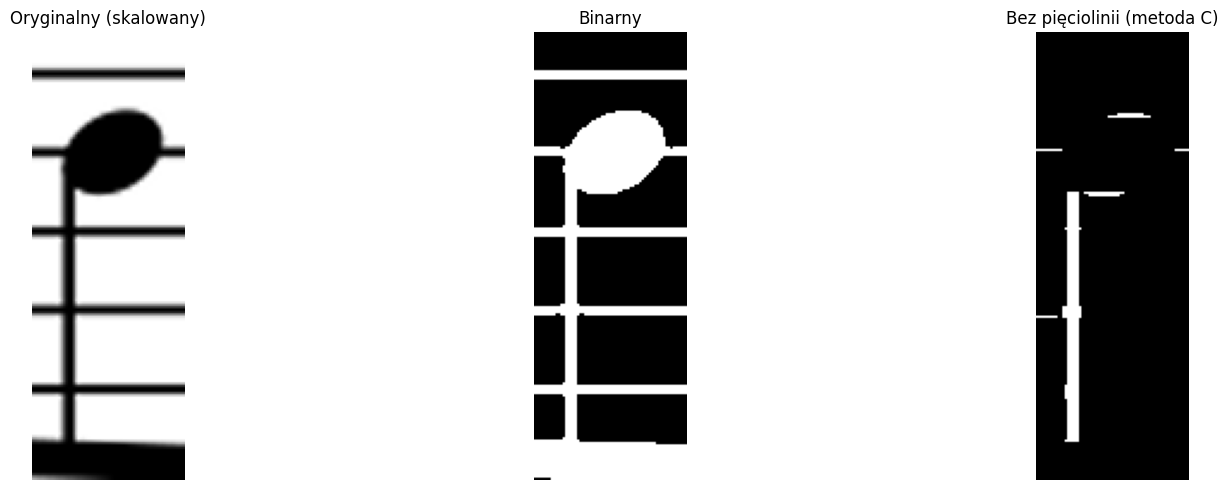

Gotowe. Funkcja remove_staff_lines() jest gotowa do importu w pipeline GHT.


In [9]:
def remove_staff_lines(binary, method='C', scale=SCALE_FACTOR, **kwargs):
    """
    Ujednolicony interfejs do usuwania linii pięciolinii.

    Args:
        binary  : obraz binarny (biały symbol, czarne tło)
        method  : 'A' (Morph OPEN), 'B' (Projection Profile), 'C' (Run-Length)
        scale   : współczynnik skalowania obrazu
        **kwargs: dodatkowe parametry przekazywane do konkretnej metody

    Returns:
        no_lines   : obraz binarny bez linii pięciolinii
        lines_mask : maska usuniętych pikseli
    """
    if method == 'A':
        return remove_lines_morph(binary, scale=scale, **kwargs)
    elif method == 'B':
        return remove_lines_projection(binary, scale=scale, **kwargs)
    elif method == 'C':
        return remove_lines_runlength(binary, scale=scale, **kwargs)
    else:
        raise ValueError(f'Nieznana metoda: {method}')


# Przykład użycia
best_result, best_mask = remove_staff_lines(binary, method='C', min_run_ratio=0.30)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img_s, cmap='gray');       axes[0].set_title('Oryginalny (skalowany)'); axes[0].axis('off')
axes[1].imshow(binary, cmap='gray');      axes[1].set_title('Binarny');                axes[1].axis('off')
axes[2].imshow(best_result, cmap='gray'); axes[2].set_title('Bez pięciolinii (metoda C)'); axes[2].axis('off')
plt.tight_layout(); plt.show()

print('Gotowe. Funkcja remove_staff_lines() jest gotowa do importu w pipeline GHT.')